# Step 3b — The reference units, one by one

Spec: `CLAUDE.md` §6 step 3b (added 2026-09-16).

The primary finding is that the imagery gate fails on the fields it most needs to catch: of the 18
units the Step 1c optical reference places in standing water on 15 March, the radar gate fires on 3
and the NDVI gate on 3. With a group this small the exhibit shows the units rather than summarising
them, so reviewers can see that the misses are not a handful of edge cases.

1. **Every reference unit**, with inundation fraction, radar flooded fraction, VV pre and post,
   ΔNDVI, clear observation counts, elevation, acreage, and which gates fired.
2. **Why did NDVI miss them?** The spec's post window opens on 20 March, nine days after the flood,
   so a fast-growing crop had time to recover before the first observation, and the pre window sits
   in a wet winter when the crop is small and mostly plastic, leaving little canopy to lose. ΔNDVI is
   recomputed over the tightest available post windows alongside the spec default. **The spec default
   is not changed**; both are reported.

**CHECKPOINT:** the per-unit table and the timing comparison. Stop before Step 4.

In [1]:
import ee
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import common as C
import optical

ee.Initialize(project=C.EE_PROJECT)

PRE_WINDOW = ("2023-02-01", "2023-03-09")
DEFAULT_POST = ("2023-03-20", "2023-05-01")     # spec default
TIGHT_POSTS = {"15 Mar only": ("2023-03-15", "2023-03-16"),
               "20 Mar only": ("2023-03-20", "2023-03-21"),
               "25 Mar only": ("2023-03-25", "2023-03-26"),
               "20-31 Mar": ("2023-03-20", "2023-04-01")}
FLOODED_MIN, NDVI_TRIGGER, S1_TRIGGER = 0.3, -0.15, 0.3

counties_fc = ee.FeatureCollection(C.COUNTIES).filter(ee.Filter.inList("GEOID", C.COUNTY_GEOIDS))
region = counties_fc.geometry()
units_fc = ee.FeatureCollection(C.UNITS_ASSET).filter(ee.Filter.eq("is_unit", 1))

ndvi = pd.read_csv(C.DERIVED / "03_units_ndvi.csv")
s1 = pd.read_csv(C.DERIVED / "02_units_s1_flood.csv")
back = pd.read_csv(C.DERIVED / "02b_field_backscatter.csv").rename(columns={"field_id": "unit_id"})
conf = pd.read_csv(C.DERIVED / "02c_units_confound.csv")
conf = conf.drop(columns=[c for c in ("unit_id",) if c in conf.columns and "field_id" in conf.columns])
conf = conf.rename(columns={"field_id": "unit_id"})
for d in (ndvi, s1, back, conf):
    d["unit_id"] = d.unit_id.astype(str)

u = (ndvi[["unit_id", "COUNTY", "ACRES", "pre_ndvi", "post_ndvi", "d_ndvi", "pre_n", "post_n"]]
     .merge(s1[["unit_id", "s1_vv", "s1_vh"]], on="unit_id")
     .merge(back.loc[back.crop_class == "T20", ["unit_id", "pre_vv", "post_vv", "d_vv", "opt15", "clear15"]],
            on="unit_id")
     .merge(conf[["unit_id", "elev_m", "km_to_river", "d_vv_31"]], on="unit_id", how="left"))
N_UNITS = len(u)
ref = u[u.opt15 >= FLOODED_MIN].sort_values("opt15", ascending=False).copy()
print(f"n units = {N_UNITS} | reference units (>= {FLOODED_MIN:.0%} inside the 15 March extent): {len(ref)}")
print(f"datasets: {C.S2}, {C.S1}, {C.UNITS_ASSET}")

n units = 1320 | reference units (>= 30% inside the 15 March extent): 18
datasets: COPERNICUS/S2_SR_HARMONIZED, COPERNICUS/S1_GRD, projects/cropczyk/assets/strawberry_fields_dwr_wy2023


## 1. Every reference unit

In [2]:
ref["ndvi_gate"] = (ref.d_ndvi < NDVI_TRIGGER) & (ref.post_n >= 2)
ref["s1_gate"] = ref.s1_vv > S1_TRIGGER
ref["gates_fired"] = np.select(
    [ref.ndvi_gate & ref.s1_gate, ref.ndvi_gate, ref.s1_gate],
    ["both", "NDVI", "radar"], default="none")

show = ref.assign(
    inundated=(100 * ref.opt15).round(0).astype(int),
    clear_view=(100 * ref.clear15).round(0).astype(int),
)[["unit_id", "COUNTY", "ACRES", "elev_m", "inundated", "clear_view", "s1_vv", "pre_vv", "post_vv",
   "d_vv", "pre_ndvi", "post_ndvi", "d_ndvi", "pre_n", "post_n", "gates_fired"]]
print("Reference units, sorted by inundation fraction. 'inundated' and 'clear_view' are percentages;")
print("s1_vv is the radar flooded fraction; VV values are dB; NDVI windows are the spec defaults.")
print(show.round(2).to_string(index=False))
print()
print("gates fired:", ref.gates_fired.value_counts().to_dict())
fell, rose = ref[ref.d_vv < 0], ref[ref.d_vv >= 0]
print(f"reference units where VV FELL: {len(fell)}, radar gate fired on {int(fell.s1_gate.sum())}")
print(f"reference units where VV ROSE: {len(rose)}, radar gate fired on {int(rose.s1_gate.sum())}")
print("The radar gate fires only where backscatter fell. On mulched beds it rose, which is the")
print("Step 2b mechanism showing up unit by unit.")
print(f"counties represented: {ref.COUNTY.value_counts().to_dict()}")
print(f"units at >= 95% inundation: {int((ref.opt15 >= 0.95).sum())}, of which radar flooded "
      f"fraction exactly 0: {int(((ref.opt15 >= 0.95) & (ref.s1_vv == 0)).sum())}")
print(f"their ΔNDVI range: {ref.loc[ref.opt15 >= 0.95, 'd_ndvi'].min():+.3f} to "
      f"{ref.loc[ref.opt15 >= 0.95, 'd_ndvi'].max():+.3f} against a {NDVI_TRIGGER} trigger")
ref.to_csv(C.DERIVED / "03b_reference_units.csv", index=False)
print("Wrote 03b_reference_units.csv")
print(f"n units = {N_UNITS} | date window: pre {PRE_WINDOW[0]} to 2023-03-08; NDVI post "
      f"{DEFAULT_POST[0]} to 2023-04-30; S1 post 2023-03-19; optical 2023-03-15 | "
      f"datasets: {C.S2}, {C.S1}, {C.UNITS_ASSET}")

Reference units, sorted by inundation fraction. 'inundated' and 'clear_view' are percentages;
s1_vv is the radar flooded fraction; VV values are dB; NDVI windows are the spec defaults.
unit_id   COUNTY  ACRES  elev_m  inundated  clear_view  s1_vv  pre_vv  post_vv  d_vv  pre_ndvi  post_ndvi  d_ndvi  pre_n  post_n gates_fired
2717328 Monterey  42.33    6.85        100         100   0.00   -8.26    -4.16  4.10      0.08       0.07   -0.02   3.00    7.00        none
2726550 Monterey  14.25    6.54        100         100   0.00   -7.93    -6.81  1.13      0.10       0.05   -0.04   3.00    7.00        none
2726604 Monterey  12.79    6.35        100         100   0.00   -7.28    -3.20  4.09      0.16       0.06   -0.10   3.00    7.00        none
2726556 Monterey   2.59    5.77         99         100   0.00  -13.38    -9.46  3.92      0.17       0.09   -0.08   6.00   14.00        none
2726581 Monterey   9.51    6.42         98          98   0.00   -9.16    -4.32  4.84      0.09       0.07   -0

## 2. Was the NDVI miss a timing artefact?

ΔNDVI recomputed against tighter post windows, including the flood observation itself on 15 March.
If the crop signal was there and gone before 20 March, the tight windows will show it.

In [3]:
def ndvi_median(start, end, name):
    col = optical.clear_s2(region, start, end)
    ndvi_img = col.map(lambda im: im.normalizedDifference(["B8", "B4"]).rename("ndvi"))
    return (ndvi_img.median().rename(name)
            .addBands(ndvi_img.count().rename(name + "_n").unmask(0)))


TIMING = C.DERIVED / "03b_ndvi_timing.csv"
if TIMING.exists():
    tim = pd.read_csv(TIMING)
    tim["unit_id"] = tim.unit_id.astype(str)
    print(f"Loaded cached {TIMING.name}")
else:
    stack = ndvi_median(*PRE_WINDOW, "pre")
    for label, (a, b) in TIGHT_POSTS.items():
        key = label.replace(" ", "_").replace("-", "_")
        stack = stack.addBands(ndvi_median(a, b, key))
    ids = u.unit_id.tolist()
    bands = ["pre", "pre_n"] + [k for label in TIGHT_POSTS
                                for k in (label.replace(" ", "_").replace("-", "_"),
                                          label.replace(" ", "_").replace("-", "_") + "_n")]
    out = []
    for i in range(0, len(ids), 200):
        part = units_fc.filter(ee.Filter.inList("unit_id", ids[i:i + 200]))
        red = stack.reduceRegions(part, ee.Reducer.mean(), scale=10, tileScale=16)
        out += [f["properties"] for f in
                red.select(["unit_id"] + bands, retainGeometry=False).getInfo()["features"]]
    tim = pd.DataFrame(out)
    tim["unit_id"] = tim.unit_id.astype(str)
    tim.to_csv(TIMING, index=False)
    print(f"Wrote {TIMING.name}")

t = u.merge(tim, on="unit_id", how="left")
is_ref = t.opt15 >= FLOODED_MIN
rows = []
for label in ["spec default (20 Mar - 30 Apr)"] + list(TIGHT_POSTS):
    if label.startswith("spec"):
        d_ref, d_dry = t.loc[is_ref, "d_ndvi"], t.loc[t.opt15 <= 0.05, "d_ndvi"]
        obs = t.loc[is_ref, "post_n"]
    else:
        key = label.replace(" ", "_").replace("-", "_")
        d = t[key] - t.pre
        d_ref, d_dry = d[is_ref], d[t.opt15 <= 0.05]
        obs = t.loc[is_ref, key + "_n"]
    rows.append({"post window": label,
                 "reference units with data": int(d_ref.notna().sum()),
                 "median clear obs": obs.median(),
                 "reference median ΔNDVI": d_ref.median(),
                 "reference 10th pct": d_ref.quantile(0.1),
                 "dry median ΔNDVI": d_dry.median(),
                 "reference units below -0.15": int((d_ref < NDVI_TRIGGER).sum())})
timing = pd.DataFrame(rows)
print(timing.round(3).to_string(index=False))
timing.to_csv(C.DERIVED / "03b_ndvi_timing_summary.csv", index=False)
print()

spec_hits = timing.loc[0, "reference units below -0.15"]
best = timing.iloc[1:]["reference units below -0.15"].max()
best_window = timing.iloc[1:].loc[timing.iloc[1:]["reference units below -0.15"].idxmax(), "post window"]
print("VERDICT")
print(f"  Spec default post window: {spec_hits} of {int(is_ref.sum())} reference units below the trigger.")
print(f"  Best tight window ({best_window}): {best} of {int(is_ref.sum())}.")
if best > spec_hits + 2:
    print("  The miss is substantially a TIMING artefact: the signal is present in a tighter window")
    print("  close to the event and has faded by the time the spec's window opens on 20 March.")
    print()
    print("  CAVEAT on the 15 March column, which must travel with this number: the reference units")
    print("  were DEFINED by the 15 March water mask, and NDWI shares band B8 with NDVI, so both")
    print("  fall when water covers a field. '18 of 18' on that date largely restates the reference")
    print("  definition and is not independent evidence. The informative columns are the later ones:")
    print("  3 of 18 on 20 March, 2 on 20-31 March, 1 on 25 March. The signal decays within days.")
    print("  Read together: NDVI here detects standing WATER, not crop damage. Once the water drains")
    print("  the canopy looks unchanged, so even a well-timed NDVI gate would confirm inundation")
    print("  rather than loss.")
elif best > spec_hits:
    print("  Tighter windows recover a little signal, so timing explains part of the miss but not")
    print("  most of it.")
else:
    print("  Tighter windows recover no additional units. The miss is a REAL ABSENCE OF SIGNAL, not a")
    print("  timing artefact: even observed during or days after inundation, these fields show no")
    print("  NDVI drop of the size the trigger expects. On mulched beds in late winter there is")
    print("  little canopy to lose.")
print(f"n units = {N_UNITS} | date windows: pre {PRE_WINDOW[0]} to 2023-03-08; posts as listed | "
      f"datasets: {C.S2}, {C.S2_CLOUD}")

Loaded cached 03b_ndvi_timing.csv
                   post window  reference units with data  median clear obs  reference median ΔNDVI  reference 10th pct  dry median ΔNDVI  reference units below -0.15
spec default (20 Mar - 30 Apr)                         18             7.542                  -0.050              -0.152             0.053                            3
                   15 Mar only                         18             1.000                  -0.399              -0.539             0.013                           18
                   20 Mar only                         17             1.000                  -0.062              -0.213             0.014                            3
                   25 Mar only                         18             1.000                  -0.037              -0.134             0.036                            1
                     20-31 Mar                         18             2.000                  -0.038              -0.160            

## Figure — the reference units and the timing test

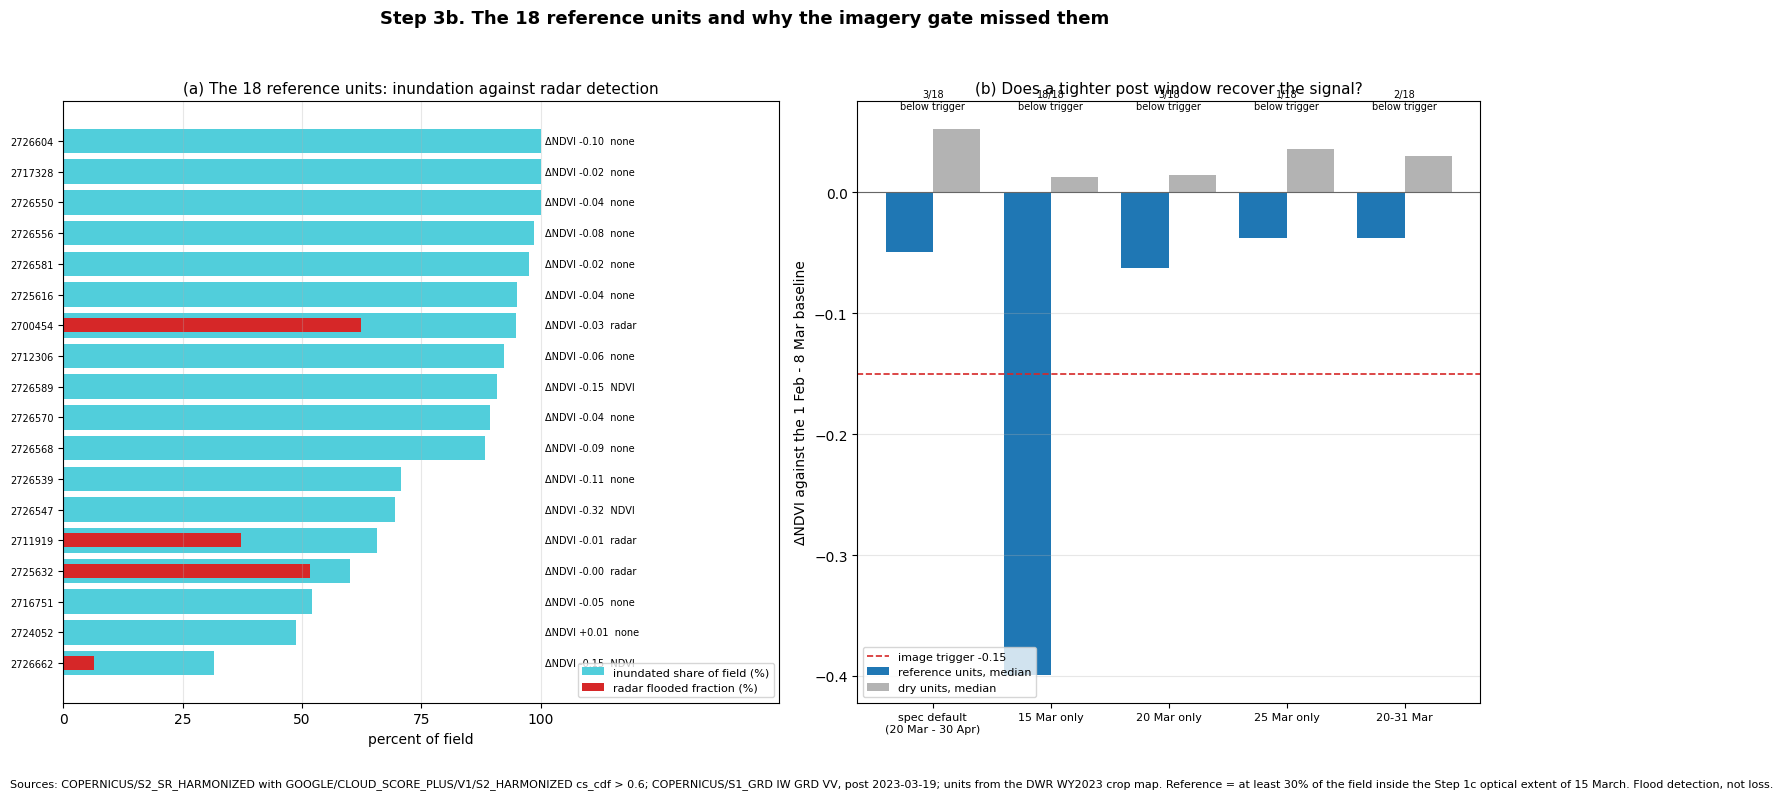

Saved supp_reference_units.png
n units = 1320 | reference units 18 | datasets: COPERNICUS/S2_SR_HARMONIZED, COPERNICUS/S1_GRD


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8), gridspec_kw={"width_ratios": [1.15, 1]})

ax = axes[0]
r = ref.sort_values("opt15")
y = np.arange(len(r))
ax.barh(y, 100 * r.opt15, color="tab:cyan", alpha=0.75, label="inundated share of field (%)")
ax.barh(y, 100 * r.s1_vv, height=0.45, color="tab:red", label="radar flooded fraction (%)")
for i, (_, row) in enumerate(r.iterrows()):
    ax.text(101, i, f"ΔNDVI {row.d_ndvi:+.2f}  {row.gates_fired}", va="center", fontsize=7)
ax.set_yticks(y)
ax.set_yticklabels(r.unit_id, fontsize=7)
ax.set_xlim(0, 150)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xlabel("percent of field")
ax.set_title(f"(a) The {len(ref)} reference units: inundation against radar detection", fontsize=11)
ax.grid(alpha=0.3, axis="x")
ax.legend(fontsize=8, loc="lower right")

ax2 = axes[1]
labels = list(timing["post window"])
xs = np.arange(len(labels))
ax2.bar(xs - 0.2, timing["reference median ΔNDVI"], width=0.4, color="tab:blue",
        label="reference units, median")
ax2.bar(xs + 0.2, timing["dry median ΔNDVI"], width=0.4, color="0.7", label="dry units, median")
ax2.axhline(NDVI_TRIGGER, color="tab:red", ls="--", lw=1.2, label=f"image trigger {NDVI_TRIGGER}")
ax2.axhline(0, color="0.4", lw=0.8)
for i, n in enumerate(timing["reference units below -0.15"]):
    ax2.text(i, ax2.get_ylim()[1] * 0.92, f"{int(n)}/{len(ref)}\nbelow trigger", ha="center", fontsize=7)
ax2.set_xticks(xs)
ax2.set_xticklabels([l.replace(" (", "\n(") for l in labels], fontsize=8)
ax2.set_ylabel("ΔNDVI against the 1 Feb - 8 Mar baseline")
ax2.set_title("(b) Does a tighter post window recover the signal?", fontsize=11)
ax2.grid(alpha=0.3, axis="y")
ax2.legend(fontsize=8, loc="lower left")

fig.suptitle("Step 3b. The 18 reference units and why the imagery gate missed them",
             fontsize=13, fontweight="bold")
fig.text(0.01, 0.005,
         f"Sources: {C.S2} with {C.S2_CLOUD} cs_cdf > {C.CLEAR_CS_CDF}; {C.S1} IW GRD VV, post "
         f"2023-03-19; units from the DWR WY2023 crop map. Reference = at least "
         f"{FLOODED_MIN:.0%} of the field inside the Step 1c optical extent of 15 March. "
         f"Flood detection, not loss.",
         fontsize=8, va="bottom")
fig.tight_layout(rect=(0, 0.04, 1, 0.95))
FIG = C.FIGURES / "supp_reference_units.png"
fig.savefig(FIG, dpi=200)
plt.show()
print(f"Saved {FIG.name}")
print(f"n units = {N_UNITS} | reference units {len(ref)} | datasets: {C.S2}, {C.S1}")